# Introduction to Diffusion Models

This notebook provides an interactive introduction to diffusion models.

## What You'll Learn

1. Understanding the forward diffusion process (adding noise)
2. Visualizing how noise is added over time
3. Understanding the reverse process (denoising)
4. Basic concepts of diffusion models

In [8]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

# Add parent directory to path
sys.path.append('..')

from src.utils.scheduler import linear_beta_schedule, cosine_beta_schedule, extract
from src.models.diffusion import DiffusionModel
from src.models.unet import UNet


## 1. Understanding the Forward Diffusion Process

Let's visualize how noise is gradually added to an image.


In [9]:
# Load a sample image (or create a simple one)
# For demonstration, we'll create a simple colored image
image = Image.new('RGB', (64, 64), color='blue')
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
])

x0 = transform(image).unsqueeze(0)  # Add batch dimension
print(f"Image shape: {x0.shape}")


Image shape: torch.Size([1, 3, 64, 64])


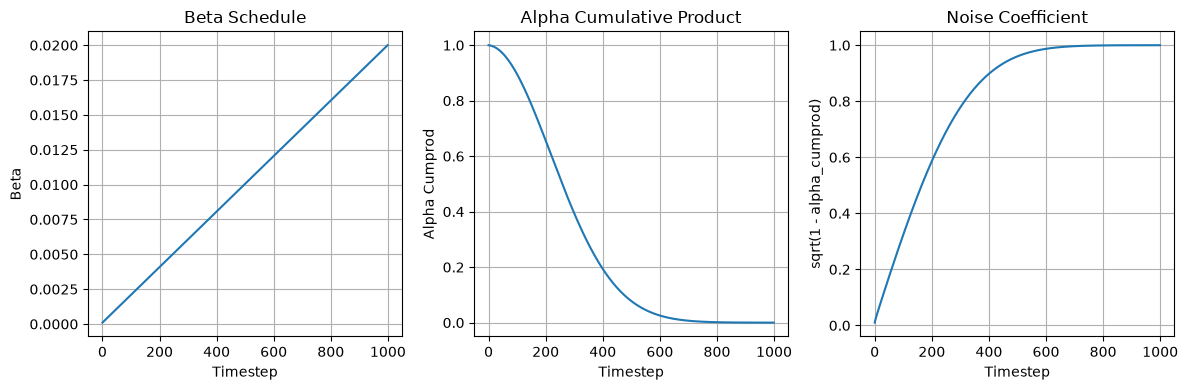

In [10]:
# Setup noise schedule
timesteps = 1000
betas = linear_beta_schedule(timesteps)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# Visualize noise schedule
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(betas.numpy())
plt.title('Beta Schedule')
plt.xlabel('Timestep')
plt.ylabel('Beta')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(alphas_cumprod.numpy())
plt.title('Alpha Cumulative Product')
plt.xlabel('Timestep')
plt.ylabel('Alpha Cumprod')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(sqrt_one_minus_alphas_cumprod.numpy())
plt.title('Noise Coefficient')
plt.xlabel('Timestep')
plt.ylabel('sqrt(1 - alpha_cumprod)')
plt.grid(True)

plt.tight_layout()
plt.show()


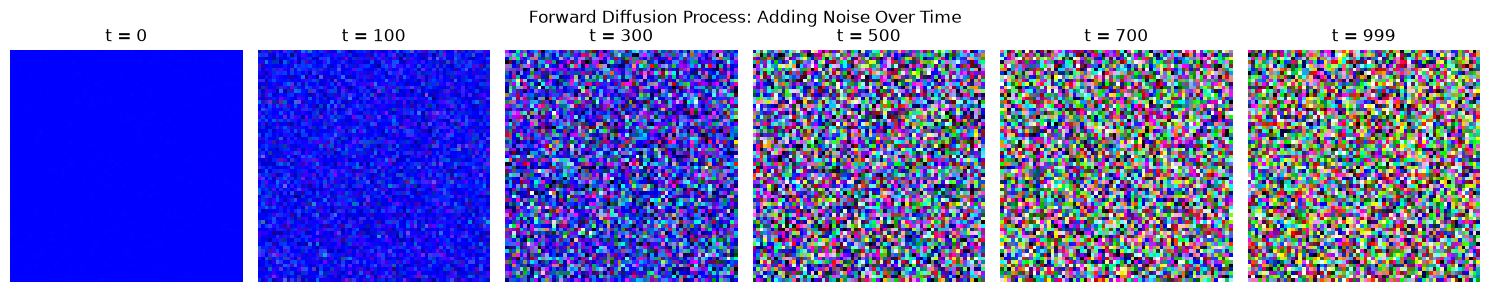

In [11]:
# Add noise at different timesteps
def add_noise(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    
    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    
    return sqrt_alphas_cumprod_t * x0 + sqrt_one_minus_alphas_cumprod_t * noise

# Visualize noise addition at different timesteps
timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val])
    x_t = add_noise(x0, t)
    
    # Denormalize for visualization
    img = (x_t[0].permute(1, 2, 0) + 1) / 2
    img = torch.clamp(img, 0, 1)
    
    axes[i].imshow(img.numpy())
    axes[i].set_title(f't = {t_val}')
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Forward Diffusion Process: Adding Noise Over Time', y=1.02)
plt.show()


## 2. Understanding the Model's Task

The model learns to predict the noise that was added. Let's see what this means:


Timestep: 238
Original image shape: torch.Size([1, 3, 64, 64])
Noise shape: torch.Size([1, 3, 64, 64])
Noisy image shape: torch.Size([1, 3, 64, 64])

The model's task: Given x_t and t, predict ε


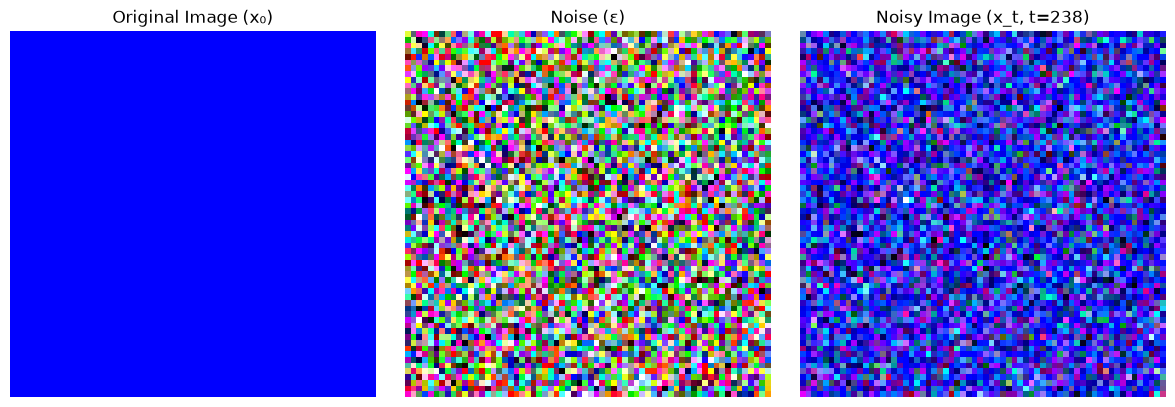

In [12]:
# At a random timestep, we have:
# 1. Original image x0
# 2. Random noise ε
# 3. Noisy image xt = sqrt(alpha_cumprod) * x0 + sqrt(1 - alpha_cumprod) * ε

t = torch.randint(0, timesteps, (1,))
noise = torch.randn_like(x0)
x_t = add_noise(x0, t, noise)

print(f"Timestep: {t.item()}")
print(f"Original image shape: {x0.shape}")
print(f"Noise shape: {noise.shape}")
print(f"Noisy image shape: {x_t.shape}")
print(f"\nThe model's task: Given x_t and t, predict ε")

# Visualize the relationship
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
img_orig = (x0[0].permute(1, 2, 0) + 1) / 2
axes[0].imshow(torch.clamp(img_orig, 0, 1).numpy())
axes[0].set_title('Original Image (x₀)')
axes[0].axis('off')

# Noise
noise_vis = (noise[0].permute(1, 2, 0) + 1) / 2
axes[1].imshow(torch.clamp(noise_vis, 0, 1).numpy())
axes[1].set_title('Noise (ε)')
axes[1].axis('off')

# Noisy
img_noisy = (x_t[0].permute(1, 2, 0) + 1) / 2
axes[2].imshow(torch.clamp(img_noisy, 0, 1).numpy())
axes[2].set_title(f'Noisy Image (x_t, t={t.item()})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 3. Model Architecture Overview

Let's create a simple model and see its structure:


In [13]:
# Create a small model for demonstration
model = UNet(
    in_channels=3,
    out_channels=3,
    time_emb_dim=64,
    model_channels=64,
    channel_mult=(1, 2, 4),
    attention_resolutions=(16,),
    dropout=0.1
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Test forward pass
x_test = torch.randn(1, 3, 64, 64)
t_test = torch.randint(0, 1000, (1,))

with torch.no_grad():
    output = model(x_test, t_test)

print(f"\nInput shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Timestep: {t_test.item()}")
print(f"\n✓ Model successfully predicts noise shape matching input!")


Total parameters: 7,316,163

Input shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 3, 64, 64])
Timestep: 350

✓ Model successfully predicts noise shape matching input!


## 4. Comparing Noise Schedules

Let's compare linear and cosine noise schedules:


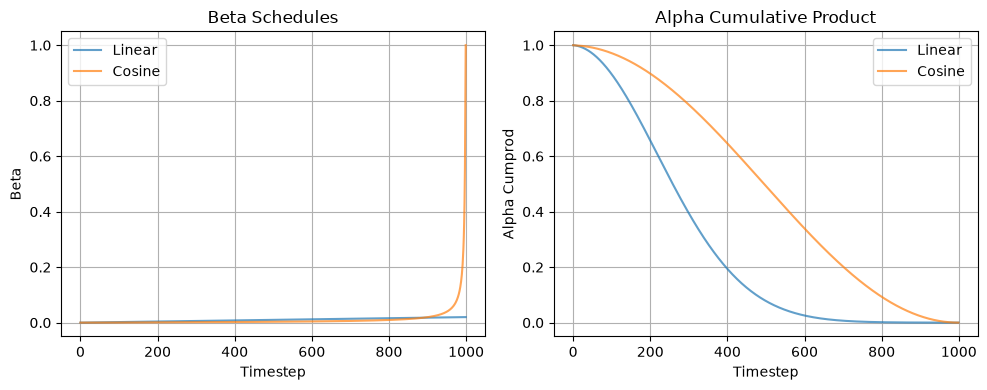

Cosine schedule adds noise more slowly at the beginning and end,
which often leads to better quality images.


In [14]:
# Compare schedules
betas_linear = linear_beta_schedule(1000)
betas_cosine = cosine_beta_schedule(1000)

alphas_cumprod_linear = torch.cumprod(1 - betas_linear, dim=0)
alphas_cumprod_cosine = torch.cumprod(1 - betas_cosine, dim=0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(betas_linear.numpy(), label='Linear', alpha=0.7)
plt.plot(betas_cosine.numpy(), label='Cosine', alpha=0.7)
plt.title('Beta Schedules')
plt.xlabel('Timestep')
plt.ylabel('Beta')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(alphas_cumprod_linear.numpy(), label='Linear', alpha=0.7)
plt.plot(alphas_cumprod_cosine.numpy(), label='Cosine', alpha=0.7)
plt.title('Alpha Cumulative Product')
plt.xlabel('Timestep')
plt.ylabel('Alpha Cumprod')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Cosine schedule adds noise more slowly at the beginning and end,")
print("which often leads to better quality images.")


## Key Takeaways

1. **Forward Process**: Gradually adds noise to images over T timesteps
2. **Reverse Process**: Model learns to remove noise step by step
3. **Training**: Model predicts the noise ε given noisy image x_t and timestep t
4. **Sampling**: Start with pure noise and iteratively denoise to generate new images

## Next Steps

Continue to the next notebook to explore data preparation and training!
